In [ ]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

In [3]:
from pathlib import Path

# path = Path(
#     "src/data/foliage/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/"
#     "MAP/ESA_WorldCover_10m_2021_v200_N30W117_Map/"
#     "ESA_WorldCover_10m_2021_v200_N30W117_Map.tif"
# ).resolve()

path = Path(
    "src/data/vegetation/"
    "ESA_WorldCover_10m_2021_v200_N30W117_Map.tif"
).resolve()

print(path)

C:\Users\DavidLim\Projects\sandbox\scenic-route\processing\src\data\vegetation\ESA_WorldCover_10m_2021_v200_N30W117_Map.tif


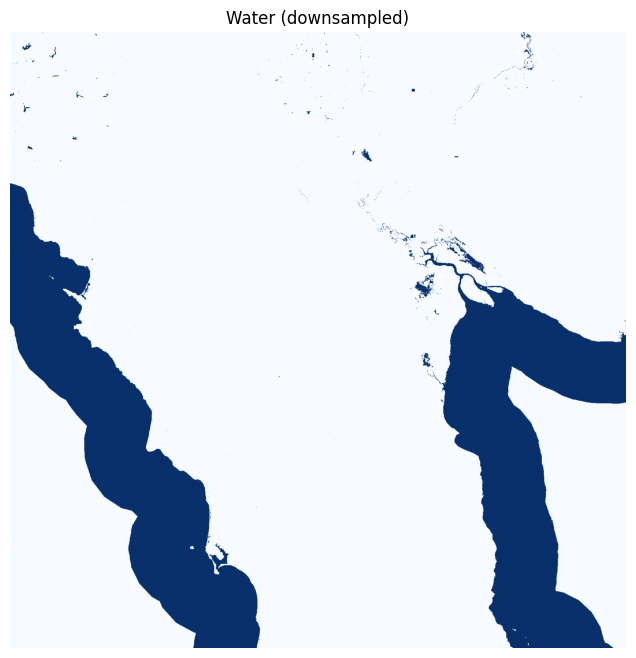

In [4]:
with rasterio.open(path) as src:
    scale = 20  # increase if you still hit memory limits
    data = src.read(
        1,
        out_shape=(
            src.height // scale,
            src.width // scale
        ),
        resampling=Resampling.nearest
    )

# Extract water (ESA WorldCover: 80 = water)
water = data == 80


plt.figure(figsize=(8, 8))
plt.imshow(water, cmap="Blues")
plt.title("Water (downsampled)")
plt.axis("off")
plt.show()


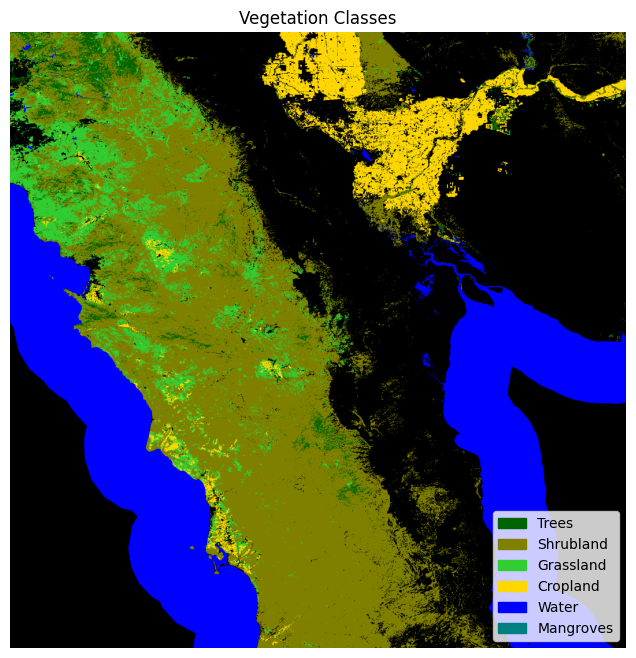

In [13]:
import matplotlib.patches as mpatches
import numpy as np

veg = np.zeros_like(data, dtype=np.uint8)

veg[data == 10] = 1  # trees
veg[data == 20] = 2  # shrub
veg[data == 30] = 3  # grass
veg[data == 40] = 4  # crops
veg[data == 80] = 5  # water
veg[data == 95] = 6  # mangroves

from matplotlib.colors import ListedColormap

cmap = ListedColormap(
    [
        "black",  # 0 = background
        "darkgreen",  # 1 = trees
        "olive",  # 2 = shrub
        "limegreen",  # 3 = grass
        "gold",  # 4 = crops
        "blue",  # 5 = water
        "teal",  # 6 = mangroves
    ]
)

plt.figure(figsize=(8, 8))
plt.imshow(veg, cmap=cmap, vmin=0, vmax=6)
plt.title("Vegetation Classes")
plt.axis("off")

legend_items = [
    mpatches.Patch(color="darkgreen", label="Trees"),
    mpatches.Patch(color="olive", label="Shrubland"),
    mpatches.Patch(color="limegreen", label="Grassland"),
    mpatches.Patch(color="gold", label="Cropland"),
    mpatches.Patch(color="blue", label="Water"),
    mpatches.Patch(color="teal", label="Mangroves"),
]

plt.legend(handles=legend_items, loc="lower right", frameon=True)


plt.show()